# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:** Muhammad Hussain


**Student ID:** 023-24-0003


**Section:** B


**GitHub Profile:** hussainwaseer


**GitHub Repo link:** [hussainwaseer](https://github.com/hussainwaseer/machine-learning-lab-3)


**Kaggle Profile:** 


**Dataset:** Telco Customer Churn


**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
# YOUR CODE HERE
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("clean_churn.csv")
print("SHAPE: ",df.shape)
print("Missing values: ", df.isnull().sum())
print("Churn distributions: ")
print(df["Churn"].value_counts())


SHAPE:  (7043, 21)
Missing values:  customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Churn distributions: 
Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Answer 2:**
The goal of this machine learning project is to predict whether a Telco customer will churn or remain with the company. This is important for the business because predicting customers who are likely to leave can help the company take action to improve customer retention.

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [6]:
# Additional verification if needed (dtypes, target check, etc.)
print("SHAPE: ", df.shape)
print(df.info())
print(df.isnull().sum())
print(df["Churn"].value_counts())

SHAPE:  (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   

---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [5]:
# Task 3 — define y and X
y = df["Churn"].map({"No": 0, "Yes":  1})
x = df.drop(columns=["Churn", "customerID"])
print("Missing values", x.isnull().sum())
print("X datatype: ",x.dtypes)


Missing values gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64
X datatype:  gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
dtype: ob

In [7]:
# Task 4 — encode categorical columns in X
x["TotalCharges"] = pd.to_numeric(x["TotalCharges"], errors="coerce")
x = pd.get_dummies(x, dtype=int)

x["TotalCharges"] = x["TotalCharges"].fillna(0)

print("X data types:")
print(x.dtypes)
print("\nMissing values:")
print(x.isnull().sum())

X data types:
SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                int64
gender_Male                                  int64
Partner_No                                   int64
Partner_Yes                                  int64
Dependents_No                                int64
Dependents_Yes                               int64
PhoneService_No                              int64
PhoneService_Yes                             int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64
OnlineSecurity_No

In [8]:
# Task 5 — confirm X is fully numeric with no missing values
print("X data types:")
print(x.dtypes)
print("\nMissing values:")
print(x.isnull().sum())

X data types:
SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                int64
gender_Male                                  int64
Partner_No                                   int64
Partner_Yes                                  int64
Dependents_No                                int64
Dependents_Yes                               int64
PhoneService_No                              int64
PhoneService_Yes                             int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64
OnlineSecurity_No

**Answer 4 (encoding method & justification):**
Encoding Justification:
I used one-hot encoding because the categorical features contain categories that do not have a meaningful numerical order. One-hot encoding converts each category into a separate binary column, avoiding the assumption that one category is greater or smaller than another.

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [15]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split
xTrain , xTest , yTrain, yTest = train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)

The dataset was split into 80% training data and 20% test data. stratify=y is sensible because the Churn target is imbalanced, with 5,174 customers who did not churn and 1,869 customers who churned. It helps maintain a similar proportion of both classes in the training and test sets.

In [16]:
# Task 7 — report shapes
print("xTrain: ",xTrain.shape)
print("xTest: ",xTest.shape)
print("yTrain: ",yTrain.shape)
print("yTest: ",yTest.shape)

xTrain:  (5634, 45)
xTest:  (1409, 45)
yTrain:  (5634,)
yTest:  (1409,)


**Answer 6 (why stratify=y):**
The dataset was split into 80% training data and 20% test data. stratify=y is sensible because the Churn target is imbalanced, with 5,174 customers who did not churn and 1,869 customers who churned. It helps maintain a similar proportion of both classes in the training and test sets

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [18]:
# Task 8 — train baseline Decision Tree and predict on train/test
from sklearn.tree import DecisionTreeClassifier
deicisionTree = DecisionTreeClassifier(random_state=42)
deicisionTree.fit(xTrain,yTrain)
yTrainPredic = deicisionTree.predict(xTrain)
yTestPredic = deicisionTree.predict(xTest)


In [19]:
# Task 9 — check the fitted tree's depth
print("depth: ",deicisionTree.get_depth())

depth:  23


**Answer 9:**
The Decision Tree grew to a depth of 23 using the default settings. This is not too surprising because no max_depth limit was specified, so the tree was allowed to keep splitting the training data until the default stopping conditions were reached. 

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [21]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
accuracy = accuracy_score(yTest,yTestPredic)
precision = precision_score(yTest,yTestPredic)
recall =  recall_score(yTest,yTestPredic)
f1Score = f1_score(yTest,yTestPredic)

print("Accuracy: ",accuracy)
print("Precision: ",precision)
print("Recall: ",recall)
print("F1 score: ",f1Score)

Accuracy:  0.7196593328601846
Precision:  0.4730077120822622
Recall:  0.4919786096256685
F1 score:  0.48230668414154654


**Task 10 — Results Table**

| Metric | Value |
|---|---|
| Accuracy | 0.7169|
| Precision | 0.4730|
| Recall |0.4919 |
| F1-score | 0.4823|

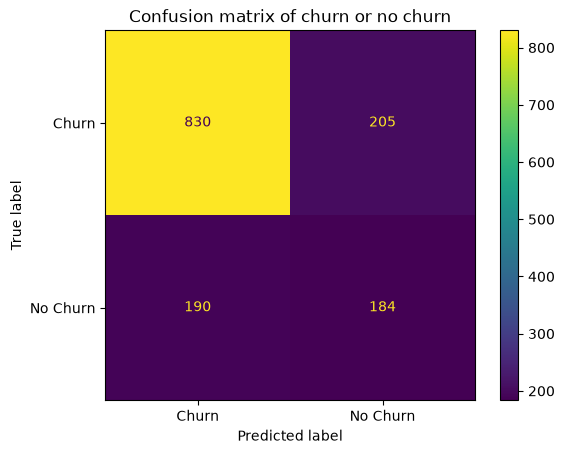

In [22]:
# Task 11 — plot the confusion matrix
cm = confusion_matrix(yTest,yTestPredic)
displayCM = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Churn","No Churn"])
displayCM.plot()
plt.title("Confusion matrix of churn or no churn")
plt.show()

**Answer 11 (churners correctly caught vs. missed):**
The model correctly identified 830 out of 1,035 churners, while it missed 205 churners. Therefore, it caught about 80.2% of the actual churners and missed about 19.8%.

**Answer 12 (which metric(s) do you trust most, and why):**
I trust recall most because the goal is to identify customers who are actually going to churn. A false negative means a customer who churns is incorrectly predicted as staying, so recall tells us how many actual churners the model successfully catches. Precision and accuracy are also useful, but recall is particularly important when missing a churner is costly.

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [ ]:
# Task 13 — compare baseline train vs. test accuracy


**Answer 13:**
_(your answer here)_

In [ ]:
# Task 14 — loop over max_depth values, record train/test accuracy
depths = [2, 3, 4, 5, 6, 8, 10, None]
# YOUR CODE HERE


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 | | |
| 3 | | |
| 4 | | |
| 5 | | |
| 6 | | |
| 8 | | |
| 10 | | |
| None | | |

In [ ]:
# Task 15 — plot train vs. test accuracy against max_depth


**Answer 15 (where overfitting starts, and why):**
_(your answer here)_

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
_(your answer here)_

In [ ]:
# Task 17 — retrain at chosen depth and report full evaluation metrics


**Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = ___) |
|---|---|---|
| Accuracy | | |
| Precision | | |
| Recall | | |
| F1-score | | |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

In [ ]:
# Task 18 — extract and visualize feature importances


**Answer 18 (top 3–5 features):**
_(your answer here)_

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**
_(your answer here)_

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
_(your answer here)_

**Answer 21 — Next steps:**
_(your answer here)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted